# Ablation Study + Statistical Significance Test
## Battery SOH Estimation — CNN-BiLSTM-Attention Framework

---

### 📋 What this notebook does

This notebook contains **two major experiments** that strengthen the paper:

---

#### Part 1 — Ablation Study
We systematically remove components from our full model to measure the individual contribution of each part:

| # | Model Variant | CNN | BiLSTM | Attention | GAN Aug. |
|---|---------------|-----|--------|-----------|----------|
| 1 | BiLSTM-only (baseline) | ❌ | ✅ | ❌ | ❌ |
| 2 | CNN + BiLSTM | ✅ | ✅ | ❌ | ❌ |
| 3 | CNN + Attention | ✅ | ❌ | ✅ | ❌ |
| 4 | **Full: CNN + BiLSTM + Attention (Real-only)** | ✅ | ✅ | ✅ | ❌ |
| 5 | **Full: CNN + BiLSTM + Attention + GAN (Proposed)** | ✅ | ✅ | ✅ | ✅ |

This shows:
- Why each component (CNN, BiLSTM, Attention) matters
- Why GAN augmentation adds value over the full model trained on real data only

---

#### Part 2 — Statistical Significance Test
We use a **paired t-test** and **Wilcoxon signed-rank test** to verify that the difference between Real-only and Augmented model performance is statistically significant (not just due to random variation).

---

### 📁 Required Inputs
- **Phase 2 outputs**: `nasa_gaf_images.npz`, `nasa_gaf_minmax.pkl`, `nasa_gaf_labels.csv`
- **Phase 3 outputs**: `cwdcgan_generator.keras`, `nasa_gaf_labels_with_split.csv`

Same datasets as Phase 5 main.

---
> **Note:** Each cell below has a description box explaining exactly what the code does and why. Run cells top to bottom in order.


---
## ⚙️ Cell 1 — Setup & Library Imports

**What this cell does:**
- Imports all necessary libraries (TensorFlow, NumPy, Pandas, SciPy, Matplotlib)
- Sets random seeds for reproducibility (seed=42 throughout)
- Defines file paths for Phase 2 and Phase 3 outputs
- Loads all required data: GAF images, min-max scaling parameters, split labels, and the trained GAN generator
- Prints a summary to confirm everything loaded correctly

**Why we need all these libraries:**
- `tensorflow` — building and training neural network models
- `scipy.stats` — paired t-test and Wilcoxon signed-rank test
- `sklearn.metrics` — RMSE, MAE, R² calculation
- `sklearn.preprocessing` — StandardScaler for signal normalization
- `itertools` — for generating model prediction sets across multiple runs


In [1]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from scipy import stats

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# ── File paths ──────────────────────────────────────────────────
PHASE2_DIR  = "/kaggle/input/datasets/tasniaturin12/nasa-gaf-phase2-output"
PHASE3_DIR  = "/kaggle/input/datasets/tasniaturin12/nasa-gaf-phase3-output"
OUTPUT_DIR  = "/kaggle/working"
NOISE_DIM   = 100
NUM_CLASSES = 3
TARGET_LEN  = 128
N_RUNS      = 5    # number of independent training runs per model (for statistical testing)

# ── Load data ───────────────────────────────────────────────────
print("Loading GAF images...")
images_array = np.load(os.path.join(PHASE2_DIR, "nasa_gaf_images.npz"))["images"]

print("Loading min-max parameters...")
with open(os.path.join(PHASE2_DIR, "nasa_gaf_minmax.pkl"), "rb") as f:
    gaf_minmax = pickle.load(f)

print("Loading labels...")
labels_df  = pd.read_csv(os.path.join(PHASE2_DIR, "nasa_gaf_labels.csv"))
split_df   = pd.read_csv(os.path.join(PHASE3_DIR, "nasa_gaf_labels_with_split.csv"))

print("Loading trained GAN generator...")
generator = tf.keras.models.load_model(
    os.path.join(PHASE3_DIR, "cwdcgan_generator.keras")
)

print()
print("=" * 50)
print(f"  GAF images loaded : {images_array.shape}")
print(f"  Total label rows  : {len(labels_df)}")
print(f"  Split breakdown   : {split_df['split'].value_counts().to_dict()}")
print(f"  GPU devices       : {tf.config.list_physical_devices('GPU')}")
print("=" * 50)


Loading GAF images...
Loading min-max parameters...
Loading labels...
Loading trained GAN generator...


I0000 00:00:1783261506.367061      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783261506.369924      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



  GAF images loaded : (2544, 128, 128, 3)
  Total label rows  : 2544
  Split breakdown   : {'train': 2028, 'excluded': 387, 'test': 129}
  GPU devices       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


---
## 🔧 Cell 2 — Helper Functions: Inverse-GAF, Signal Builder, Synthetic Generator

**What this cell does:**
Defines all the reusable functions that the rest of the notebook depends on.

**Functions defined here:**

1. **`soh_to_bin(soh)`**
   Converts a continuous SOH value into one of 3 degradation-stage bins:
   - Bin 0 = Fresh (SOH ≥ 85%)
   - Bin 1 = Mid-life (70% ≤ SOH < 85%)
   - Bin 2 = Aged (SOH < 70%)
   These bins were used to condition the GAN during Phase 3 training.

2. **`inverse_gasf_diag(image_channel, min_val, max_val)`**
   Reconstructs a 1D time-series signal from the diagonal of a GASF matrix.
   Mathematical formula:
   - φᵢ = 0.5 × arccos(GASF(i,i))
   - x'ᵢ = cos(φᵢ)
   - xᵢ = x'ᵢ × (max - min) + min

3. **`image_to_signals(image, minmax)`**
   Converts a 3-channel GAF image [128×128×3] back to a [128×3] signal array
   (Voltage, Current, Temperature), using the stored min-max values.

4. **`build_real_signals(df, images_arr, gaf_minmax)`**
   Loops through a dataframe of cycle metadata, finds the matching GAF image,
   applies inverse-GAF with the cycle's exact min-max, and returns X (signals) and y (SOH labels).

5. **`generate_synthetic_signals(generator, n_samples, y_real_train)`**
   Uses the trained C-W-DCGAN-GP generator to produce synthetic V/I/T signals.
   SOH labels for synthetic samples are randomly drawn from the real training SOH distribution
   to ensure realistic label coverage.


In [2]:
def soh_to_bin(soh):
    """Map continuous SOH (%) to one of 3 degradation-stage bins."""
    if soh >= 85:   return 0   # Fresh
    elif soh >= 70: return 1   # Mid-life
    else:           return 2   # Aged


def inverse_gasf_diag(image_channel, min_val, max_val):
    """
    Reconstruct 1D signal from GASF matrix diagonal.
    Only the diagonal elements are needed — they directly encode
    the original signal values at each time step.
    """
    diag   = np.clip(np.diag(image_channel), -1.0, 1.0)
    phi    = 0.5 * np.arccos(diag)            # recover polar angle
    scaled = np.cos(phi)                       # recover scaled value
    return scaled * (max_val - min_val) + min_val  # rescale to physical units


def image_to_signals(image, minmax):
    """
    Convert a [128, 128, 3] RGB GAF image back to a [128, 3] signal array.
    Channel 0 → Voltage, Channel 1 → Current, Channel 2 → Temperature.
    """
    v = inverse_gasf_diag(image[:, :, 0], *minmax["voltage"])
    i = inverse_gasf_diag(image[:, :, 1], *minmax["current"])
    t = inverse_gasf_diag(image[:, :, 2], *minmax["temperature"])
    return np.stack([v, i, t], axis=-1)   # shape: [128, 3]


def build_real_signals(df, images_arr, gaf_minmax):
    """
    Build (X, y) arrays from a dataframe of cycle metadata.
    Each row → one [128, 3] signal + one SOH label.
    Uses each cycle's own per-cycle min-max for accurate reconstruction.
    """
    X, y = [], []
    for _, row in df.iterrows():
        battery = row["battery_id"]
        cycle   = int(row["source_cycle"])
        # Locate this cycle's original image index in images_array
        match = labels_df[
            (labels_df["battery_id"]   == battery) &
            (labels_df["source_cycle"] == cycle) &
            (~labels_df["is_augmented"])
        ]
        if len(match) == 0:
            continue
        img    = images_arr[match.index[0]]
        minmax = gaf_minmax[battery].get(cycle, next(iter(gaf_minmax[battery].values())))
        X.append(image_to_signals(img, minmax))
        y.append(row["SOH_percent"])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def generate_synthetic_signals(generator, n_samples, y_real_train,
                                global_minmax, noise_dim=NOISE_DIM):
    """
    Generate synthetic V/I/T signals using the trained C-W-DCGAN-GP generator.
    SOH targets are randomly sampled from the real training distribution
    so synthetic labels match the real data's SOH range.
    """
    soh_targets = np.random.choice(y_real_train, size=n_samples, replace=True)
    X_syn, y_syn = [], []
    for soh in soh_targets:
        noise = tf.random.normal([1, noise_dim])
        label = tf.constant([[soh_to_bin(float(soh))]])
        img   = generator([noise, label], training=False).numpy()[0]
        X_syn.append(image_to_signals(img, global_minmax))
        y_syn.append(soh)
    return np.array(X_syn, dtype=np.float32), np.array(y_syn, dtype=np.float32)


print("All helper functions defined successfully.")


All helper functions defined successfully.


---
## 📊 Cell 3 — Data Preparation: Train/Test Split & Signal Construction

**What this cell does:**
Prepares all the data needed for both the ablation study and statistical testing.

**Steps:**

1. **Stratified Train/Test Split (80/20)**
   Uses `StratifiedShuffleSplit` from scikit-learn to ensure that both train and test sets
   contain a proportional mix of Fresh, Mid-life, and Aged battery cycles from every battery.
   This prevents the issue (seen in earlier experiments) where test cycles were all from one
   degradation stage. Random seed = 42 (same as Phase 5 main notebook for consistency).

2. **Build Real Signals**
   Calls `build_real_signals()` on both train and test subsets to produce:
   - `X_real_train`: [N_train, 128, 3] — V/I/T signals for training
   - `X_test`: [N_test, 128, 3] — V/I/T signals for testing (held out throughout)
   - `y_real_train`, `y_test`: SOH labels in percentage

3. **Global Min-Max Reference**
   Computes per-channel (V/I/T) global min and max values from the full real training set.
   This reference is used when inverse-GAF-transforming synthetic images — ensuring that
   synthetic signals sit in the same physical value range as real signals.

4. **Generate Synthetic Signals**
   Calls `generate_synthetic_signals()` to produce N_train synthetic V/I/T signals.
   Augmented training set = real train + synthetic (same size as real train).

5. **StandardScaler Normalization**
   Fits a StandardScaler on real train signals only, then transforms real train,
   synthetic, and test sets. This puts all signals in the same feature space,
   which is critical when mixing real and synthetic data (augmented training).


In [3]:
# ── Stratified 80/20 train/test split ───────────────────────────
real_df = labels_df[~labels_df["is_augmented"]].copy().reset_index(drop=True)
real_df["soh_bin"]   = real_df["SOH_percent"].apply(soh_to_bin)
real_df["strat_key"] = real_df["battery_id"] + "_" + real_df["soh_bin"].astype(str)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
tr_idx, te_idx = next(sss.split(real_df, real_df["strat_key"]))

train_df = real_df.iloc[tr_idx].copy()
test_df  = real_df.iloc[te_idx].copy()

print("Building real signals...")
X_real_train, y_real_train = build_real_signals(train_df, images_array, gaf_minmax)
X_test,       y_test       = build_real_signals(test_df,  images_array, gaf_minmax)

# ── Global min/max (for synthetic inverse-GAF) ───────────────────
global_minmax = {
    "voltage":     (float(X_real_train[:,:,0].min()), float(X_real_train[:,:,0].max())),
    "current":     (float(X_real_train[:,:,1].min()), float(X_real_train[:,:,1].max())),
    "temperature": (float(X_real_train[:,:,2].min()), float(X_real_train[:,:,2].max())),
}

# ── Generate synthetic signals ────────────────────────────────────
print("Generating synthetic signals...")
np.random.seed(42)
X_syn, y_syn = generate_synthetic_signals(
    generator, len(X_real_train), y_real_train, global_minmax
)

X_aug = np.concatenate([X_real_train, X_syn])
y_aug = np.concatenate([y_real_train, y_syn])

# ── StandardScaler (fit on real train only) ───────────────────────
print("Normalizing signals...")
scaler = StandardScaler()
n_tr, n_te = len(X_real_train), len(X_test)
n_syn, n_aug = len(X_syn), len(X_aug)

scaler.fit(X_real_train.reshape(n_tr, -1))

X_tr_sc  = scaler.transform(X_real_train.reshape(n_tr,  -1)).reshape(n_tr,  TARGET_LEN, 3).astype(np.float32)
X_syn_sc = scaler.transform(X_syn.reshape(n_syn, -1)).reshape(n_syn, TARGET_LEN, 3).astype(np.float32)
X_te_sc  = scaler.transform(X_test.reshape(n_te,  -1)).reshape(n_te,  TARGET_LEN, 3).astype(np.float32)
X_aug_sc = np.concatenate([X_tr_sc, X_syn_sc])

# ── SOH normalization to [0,1] ────────────────────────────────────
SOH_MIN = float(y_real_train.min())
SOH_MAX = float(y_real_train.max())

def norm_soh(y):   return (y - SOH_MIN) / (SOH_MAX - SOH_MIN + 1e-8)
def denorm_soh(yn): return yn * (SOH_MAX - SOH_MIN) + SOH_MIN

y_tr_n   = norm_soh(y_real_train)
y_aug_n  = norm_soh(y_aug)

print()
print("=" * 55)
print(f"  Real train  : {X_tr_sc.shape}  | SOH: {y_real_train.min():.1f}–{y_real_train.max():.1f}%")
print(f"  Synthetic   : {X_syn_sc.shape}  | SOH: {y_syn.min():.1f}–{y_syn.max():.1f}%")
print(f"  Augmented   : {X_aug_sc.shape}  | (real + synthetic combined)")
print(f"  Test        : {X_te_sc.shape}   | SOH: {y_test.min():.1f}–{y_test.max():.1f}%")
print(f"  SOH norm range: [{norm_soh(y_real_train).min():.3f}, {norm_soh(y_real_train).max():.3f}]")
print("=" * 55)


Building real signals...
Generating synthetic signals...
Normalizing signals...

  Real train  : (508, 128, 3)  | SOH: 57.7–101.8%
  Synthetic   : (508, 128, 3)  | SOH: 58.2–101.8%
  Augmented   : (1016, 128, 3)  | (real + synthetic combined)
  Test        : (128, 128, 3)   | SOH: 57.9–100.7%
  SOH norm range: [0.000, 1.000]


---
## 🏗️ Cell 4 — Model Architecture Definitions (5 Variants)

**What this cell does:**
Defines all 5 model variants used in the ablation study as separate build functions.
Each variant is a clean function that returns a compiled Keras model.

**Why we define separate functions (not one function with flags):**
This makes the ablation completely independent — there is no shared state between variants.
Each model is built fresh for every training run, ensuring fair comparison.

**Variant details:**

---

**Variant 1 — BiLSTM Only** (`build_bilstm_only`)
- A simple Bidirectional LSTM baseline — no CNN, no attention
- Takes raw [128, 3] signals directly
- Two BiLSTM layers (64, 32 units) → Global average pooling → Dense output
- This is the simplest sequential model; serves as the lower-bound baseline

---

**Variant 2 — CNN + BiLSTM** (`build_cnn_bilstm`)
- Adds the 1D CNN feature extractor before the BiLSTM
- Two Conv1D layers (64, 128 filters) extract local patterns before LSTM processes them
- No attention mechanism — tests whether CNN alone is sufficient

---

**Variant 3 — CNN + Attention** (`build_cnn_attention`)
- CNN feature extraction + attention, but **no BiLSTM**
- After CNN, a self-attention layer weights each timestep
- Tests whether attention alone (without BiLSTM's sequential memory) is sufficient

---

**Variant 4 — Full Model: CNN + BiLSTM + Attention (Real-only)** (`build_full_model`)
- Our complete proposed architecture trained on real data only
- Isolates the contribution of the architecture itself (vs. data augmentation)

---

**Variant 5 — Full Model + GAN Augmentation (Proposed)** (same `build_full_model`)
- Identical architecture to Variant 4 but trained on real + synthetic data
- The difference in performance vs. Variant 4 shows the value of GAN augmentation

---

**Common settings across all variants:**
- Sigmoid output activation (SOH normalized to [0,1])
- Adam optimizer (lr = 1e-3)
- MSE loss
- Dropout (0.3 after CNN, 0.3 after first BiLSTM)
- BatchNormalization in CNN layers


In [4]:
# ── Shared attention block ────────────────────────────────────────
def attention_block(x):
    """
    Additive (Bahdanau-style) self-attention over the time axis.
    Computes a scalar weight αt for each timestep t,
    then returns the weighted sum: context = Σ αt * ht
    """
    score   = layers.Dense(1, activation="tanh")(x)      # [B, T, 1]
    weight  = layers.Softmax(axis=1)(score)               # [B, T, 1]
    context = layers.Multiply()([x, weight])              # [B, T, F]
    return layers.Lambda(lambda t: tf.reduce_sum(t, axis=1))(context)  # [B, F]


# ── Variant 1: BiLSTM Only ────────────────────────────────────────
def build_bilstm_only(input_shape=(TARGET_LEN, 3)):
    """Baseline: pure Bidirectional LSTM, no CNN, no attention."""
    inp = layers.Input(shape=input_shape)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(inp)
    x = layers.Dropout(0.3)(x)
    x = layers.Bidirectional(layers.LSTM(32, return_sequences=False))(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    model = Model(inp, out, name="BiLSTM_Only")
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
    return model


# ── Variant 2: CNN + BiLSTM ────────────────────────────────────────
def build_cnn_bilstm(input_shape=(TARGET_LEN, 3)):
    """Ablation: CNN + BiLSTM, no attention mechanism."""
    inp = layers.Input(shape=input_shape)
    x = layers.Conv1D(64,  3, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Bidirectional(layers.LSTM(32, return_sequences=False))(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    model = Model(inp, out, name="CNN_BiLSTM")
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
    return model


# ── Variant 3: CNN + Attention ────────────────────────────────────
def build_cnn_attention(input_shape=(TARGET_LEN, 3)):
    """Ablation: CNN + Attention, no BiLSTM."""
    inp = layers.Input(shape=input_shape)
    x = layers.Conv1D(64,  3, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.3)(x)
    x = attention_block(x)       # attention directly on CNN output (no LSTM)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    model = Model(inp, out, name="CNN_Attention")
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
    return model


# ── Variant 4 & 5: Full Model ─────────────────────────────────────
def build_full_model(input_shape=(TARGET_LEN, 3)):
    """
    Full proposed architecture: CNN + BiLSTM + Attention.
    Used for both Variant 4 (real-only training) and
    Variant 5 (augmented training with GAN synthetic data).
    """
    inp = layers.Input(shape=input_shape)
    x = layers.Conv1D(64,  3, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Bidirectional(layers.LSTM(32, return_sequences=True))(x)
    x = attention_block(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    model = Model(inp, out, name="CNN_BiLSTM_Attention")
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
    return model


# ── Print parameter counts ────────────────────────────────────────
print("Model parameter counts:")
for name, builder in [
    ("BiLSTM Only",         build_bilstm_only),
    ("CNN + BiLSTM",        build_cnn_bilstm),
    ("CNN + Attention",     build_cnn_attention),
    ("Full Model",          build_full_model),
]:
    m = builder()
    total = m.count_params()
    print(f"  {name:<30}: {total:,} parameters")


Model parameter counts:
  BiLSTM Only                   : 80,257 parameters
  CNN + BiLSTM                  : 170,369 parameters
  CNN + Attention               : 34,562 parameters
  Full Model                    : 170,434 parameters


---
## 🏋️ Cell 5 — Universal Training & Evaluation Function

**What this cell does:**
Defines one shared `train_and_evaluate()` function used for all 5 ablation variants.

**Why a single function for all variants:**
- Guarantees identical training conditions (same epochs, batch size, callbacks, evaluation procedure)
- Only the model architecture and training data change — everything else is held constant
- Eliminates any possibility of accidental bias in hyperparameter settings between variants

**Training details:**
- **Epochs:** 150 (maximum), but Early Stopping prevents overfitting
- **Batch size:** 32
- **Early Stopping:** monitors validation loss, patience = 20 epochs, restores best weights
- **Learning Rate Scheduler:** reduces LR by 50% when validation loss plateaus for 8 epochs,
  minimum LR = 1e-6 (prevents learning from stopping too early)
- **Validation split:** 15% of training data held out for monitoring during training
- **SOH labels:** normalized to [0,1] during training; denormalized back to % for metric calculation

**Multiple runs (N_RUNS = 5):**
Each model is trained 5 times with different random seeds.
This gives us a distribution of performance values, not just a single point estimate.
The distribution is needed for the statistical significance tests in Part 2.

**Metrics computed:**
- RMSE (Root Mean Squared Error) in %
- MAE (Mean Absolute Error) in %
- R² (Coefficient of Determination)


In [5]:
EPOCHS = 150
BATCH  = 32

def train_and_evaluate(build_fn, X_train, y_train_norm, X_test, y_test,
                       variant_name, n_runs=N_RUNS):
    """
    Train a model variant multiple times and collect performance metrics.

    Parameters:
    -----------
    build_fn      : function that returns a compiled Keras model
    X_train       : [N, 128, 3] normalized training signals
    y_train_norm  : [N] SOH labels normalized to [0,1]
    X_test        : [N_test, 128, 3] normalized test signals
    y_test        : [N_test] true SOH labels in % (for metric calculation)
    variant_name  : string label for logging
    n_runs        : number of independent training runs

    Returns:
    --------
    dict with lists of RMSE, MAE, R² values (one per run) +
    mean/std summaries
    """
    print(f"\nTraining: {variant_name}")
    print(f"  Train size: {len(X_train)} | Runs: {n_runs}")
    print("-" * 45)

    rmse_list, mae_list, r2_list = [], [], []

    cb_list = [
        callbacks.EarlyStopping(
            monitor="val_loss", patience=20,
            restore_best_weights=True, verbose=0
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5,
            patience=8, min_lr=1e-6, verbose=0
        ),
    ]

    for run in range(n_runs):
        seed = 42 + run * 13   # deterministic but varied seeds
        tf.random.set_seed(seed)
        np.random.seed(seed)

        model = build_fn()
        model.fit(
            X_train, y_train_norm,
            validation_split=0.15,
            epochs=EPOCHS,
            batch_size=BATCH,
            callbacks=cb_list,
            verbose=0,
        )

        pred_norm = model.predict(X_test, verbose=0).flatten()
        pred      = denorm_soh(pred_norm)

        rmse = float(np.sqrt(mean_squared_error(y_test, pred)))
        mae  = float(mean_absolute_error(y_test, pred))
        r2   = float(r2_score(y_test, pred))

        rmse_list.append(rmse)
        mae_list.append(mae)
        r2_list.append(r2)
        print(f"  Run {run+1}/{n_runs}: RMSE={rmse:.4f}%  MAE={mae:.4f}%  R²={r2:.4f}")

    result = {
        "variant":   variant_name,
        "rmse_runs": rmse_list,
        "mae_runs":  mae_list,
        "r2_runs":   r2_list,
        "RMSE_mean": round(np.mean(rmse_list), 4),
        "RMSE_std":  round(np.std(rmse_list),  4),
        "MAE_mean":  round(np.mean(mae_list),  4),
        "MAE_std":   round(np.std(mae_list),   4),
        "R2_mean":   round(np.mean(r2_list),   4),
        "R2_std":    round(np.std(r2_list),    4),
    }
    print(f"  → Mean: RMSE={result['RMSE_mean']}±{result['RMSE_std']}  "
          f"R²={result['R2_mean']}±{result['R2_std']}")
    return result


print("Training function ready.")
print(f"Each variant will be trained {N_RUNS} times with seeds: "
      f"{[42 + i*13 for i in range(N_RUNS)]}")


Training function ready.
Each variant will be trained 5 times with seeds: [42, 55, 68, 81, 94]


---
## 🚀 Cell 6 — Run Ablation Study (All 5 Variants)

**What this cell does:**
Runs all 5 ablation variants sequentially. Each variant is trained N_RUNS=5 times.

**Training data for each variant:**
- Variants 1, 2, 3, 4 → trained on **real train data only** (`X_tr_sc`, `y_tr_n`)
- Variant 5 → trained on **augmented data** (`X_aug_sc`, `y_aug_n` = real + synthetic)

**Expected runtime:** ~20-30 minutes on GPU (T4 x2)

**What to watch for during training:**
- BiLSTM-only will likely have the highest RMSE (lowest performance)
- Full model (Variant 4) should outperform ablated versions (Variants 1-3)
- Variant 5 (augmented) should show improved or comparable R² vs Variant 4

All results are stored in `ablation_results` list for later analysis and plotting.


In [6]:
ablation_configs = [
    ("1. BiLSTM Only",              build_bilstm_only,   X_tr_sc,  y_tr_n),
    ("2. CNN + BiLSTM",             build_cnn_bilstm,    X_tr_sc,  y_tr_n),
    ("3. CNN + Attention",          build_cnn_attention, X_tr_sc,  y_tr_n),
    ("4. Full Model (Real-only)",   build_full_model,    X_tr_sc,  y_tr_n),
    ("5. Full Model + GAN (Ours)",  build_full_model,    X_aug_sc, y_aug_n),
]

ablation_results = []
for name, build_fn, X_tr, y_tr in ablation_configs:
    result = train_and_evaluate(build_fn, X_tr, y_tr, X_te_sc, y_test, name)
    ablation_results.append(result)

print("\n" + "="*55)
print("ALL VARIANTS COMPLETE")
print("="*55)



Training: 1. BiLSTM Only
  Train size: 508 | Runs: 5
---------------------------------------------
  Run 1/5: RMSE=0.7636%  MAE=0.5673%  R²=0.9939
  Run 2/5: RMSE=3.2675%  MAE=2.3358%  R²=0.8892
  Run 3/5: RMSE=3.6420%  MAE=2.7629%  R²=0.8623
  Run 4/5: RMSE=3.6807%  MAE=3.1864%  R²=0.8594
  Run 5/5: RMSE=3.1207%  MAE=2.4465%  R²=0.8989
  → Mean: RMSE=2.8949±1.087  R²=0.9007±0.049

Training: 2. CNN + BiLSTM
  Train size: 508 | Runs: 5
---------------------------------------------
  Run 1/5: RMSE=0.8647%  MAE=0.6389%  R²=0.9922
  Run 2/5: RMSE=5.7788%  MAE=4.8586%  R²=0.6533
  Run 3/5: RMSE=5.5879%  MAE=4.6716%  R²=0.6759
  Run 4/5: RMSE=6.1416%  MAE=5.1500%  R²=0.6084
  Run 5/5: RMSE=5.4005%  MAE=4.5567%  R²=0.6972
  → Mean: RMSE=4.7547±1.9604  R²=0.7254±0.1366

Training: 3. CNN + Attention
  Train size: 508 | Runs: 5
---------------------------------------------


I0000 00:00:1783261691.349019      70 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  Run 1/5: RMSE=1.1533%  MAE=0.7682%  R²=0.9862
  Run 2/5: RMSE=7.8957%  MAE=6.6816%  R²=0.3528
  Run 3/5: RMSE=8.2247%  MAE=6.9833%  R²=0.2978
  Run 4/5: RMSE=8.8766%  MAE=7.5168%  R²=0.1820
  Run 5/5: RMSE=7.9469%  MAE=6.6835%  R²=0.3444
  → Mean: RMSE=6.8194±2.8545  R²=0.4326±0.2834

Training: 4. Full Model (Real-only)
  Train size: 508 | Runs: 5
---------------------------------------------
  Run 1/5: RMSE=0.9146%  MAE=0.6795%  R²=0.9913
  Run 2/5: RMSE=4.9959%  MAE=4.0716%  R²=0.7409
  Run 3/5: RMSE=5.4003%  MAE=4.3949%  R²=0.6973
  Run 4/5: RMSE=6.2457%  MAE=5.1552%  R²=0.5950
  Run 5/5: RMSE=5.4654%  MAE=4.5507%  R²=0.6899
  → Mean: RMSE=4.6044±1.8887  R²=0.7429±0.133

Training: 5. Full Model + GAN (Ours)
  Train size: 1016 | Runs: 5
---------------------------------------------
  Run 1/5: RMSE=1.0977%  MAE=0.8813%  R²=0.9875
  Run 2/5: RMSE=6.4331%  MAE=5.4859%  R²=0.5704
  Run 3/5: RMSE=5.6337%  MAE=4.7034%  R²=0.6705
  Run 4/5: RMSE=5.1542%  MAE=4.3344%  R²=0.7242
  Run 5/5: 

---
## 📋 Cell 7 — Ablation Study Results Table

**What this cell does:**
Formats all results into a clean summary table showing mean ± standard deviation
for RMSE, MAE, and R² across 5 runs for each variant.

**How to read the table:**
- Lower RMSE and MAE = better (less prediction error)
- Higher R² = better (closer to 1.0 means near-perfect prediction)
- The ± values show how stable each model is across different random seeds
- A small standard deviation means the model trains reliably

**The table answers two key questions:**
1. Does adding each component (CNN, BiLSTM, Attention) improve performance? → Variants 1-4
2. Does GAN augmentation improve performance over the full real-data model? → Variants 4 vs 5

This table will be directly included in the paper as the ablation study table.


In [7]:
# ── Build summary dataframe ──────────────────────────────────────
summary_rows = []
for r in ablation_results:
    summary_rows.append({
        "Model Variant":  r["variant"],
        "RMSE (%) ↓":    f"{r['RMSE_mean']:.4f} ± {r['RMSE_std']:.4f}",
        "MAE (%) ↓":     f"{r['MAE_mean']:.4f} ± {r['MAE_std']:.4f}",
        "R² ↑":          f"{r['R2_mean']:.4f} ± {r['R2_std']:.4f}",
    })

summary_df = pd.DataFrame(summary_rows)

print("=" * 80)
print("ABLATION STUDY RESULTS  (mean ± std over 5 independent runs)")
print("=" * 80)
print(summary_df.to_string(index=False))
print("=" * 80)
print()
print("Arrow symbols: ↓ = lower is better | ↑ = higher is better")
print()
# Also show raw mean values for easy comparison
print("Raw means (for quick comparison):")
raw_rows = []
for r in ablation_results:
    raw_rows.append({
        "Variant":     r["variant"],
        "RMSE_mean":   r["RMSE_mean"],
        "MAE_mean":    r["MAE_mean"],
        "R2_mean":     r["R2_mean"],
    })
raw_df = pd.DataFrame(raw_rows)
print(raw_df.to_string(index=False))

# Save
summary_df.to_csv(os.path.join(OUTPUT_DIR, "ablation_results.csv"), index=False)
raw_df.to_csv(os.path.join(OUTPUT_DIR, "ablation_results_raw.csv"), index=False)
print()
print("Saved: ablation_results.csv, ablation_results_raw.csv")


ABLATION STUDY RESULTS  (mean ± std over 5 independent runs)
             Model Variant      RMSE (%) ↓       MAE (%) ↓            R² ↑
            1. BiLSTM Only 2.8949 ± 1.0870 2.2598 ± 0.8963 0.9007 ± 0.0490
           2. CNN + BiLSTM 4.7547 ± 1.9604 3.9752 ± 1.6801 0.7254 ± 0.1366
        3. CNN + Attention 6.8194 ± 2.8545 5.7267 ± 2.4979 0.4326 ± 0.2834
 4. Full Model (Real-only) 4.6044 ± 1.8887 3.7704 ± 1.5850 0.7429 ± 0.1330
5. Full Model + GAN (Ours) 3.9240 ± 2.2627 3.2691 ± 1.9611 0.7870 ± 0.1690

Arrow symbols: ↓ = lower is better | ↑ = higher is better

Raw means (for quick comparison):
                   Variant  RMSE_mean  MAE_mean  R2_mean
            1. BiLSTM Only     2.8949    2.2598   0.9007
           2. CNN + BiLSTM     4.7547    3.9752   0.7254
        3. CNN + Attention     6.8194    5.7267   0.4326
 4. Full Model (Real-only)     4.6044    3.7704   0.7429
5. Full Model + GAN (Ours)     3.9240    3.2691   0.7870

Saved: ablation_results.csv, ablation_results_raw.cs

---
## 📊 Cell 8 — Ablation Study Visualizations

**What this cell does:**
Creates two publication-quality figures:

**Figure 1 — Bar Chart with Error Bars:**
- X-axis: 5 model variants
- Y-axis: RMSE (%) and R²
- Error bars show ±1 standard deviation across 5 runs
- Color coding: blue = ablated variants (1-3), orange = full model real-only (4), green = proposed (5)
- This makes it immediately clear which components contribute most

**Figure 2 — Component Contribution Heatmap:**
- Shows which components (CNN, BiLSTM, Attention, GAN) are present in each variant
- Combined with performance values in each cell
- Useful for reviewers to quickly see the ablation design

**Why error bars matter:**
Without error bars, a reviewer cannot tell if a performance difference is real or
just due to random initialization. Error bars show that our results are statistically
meaningful, not just lucky single runs.


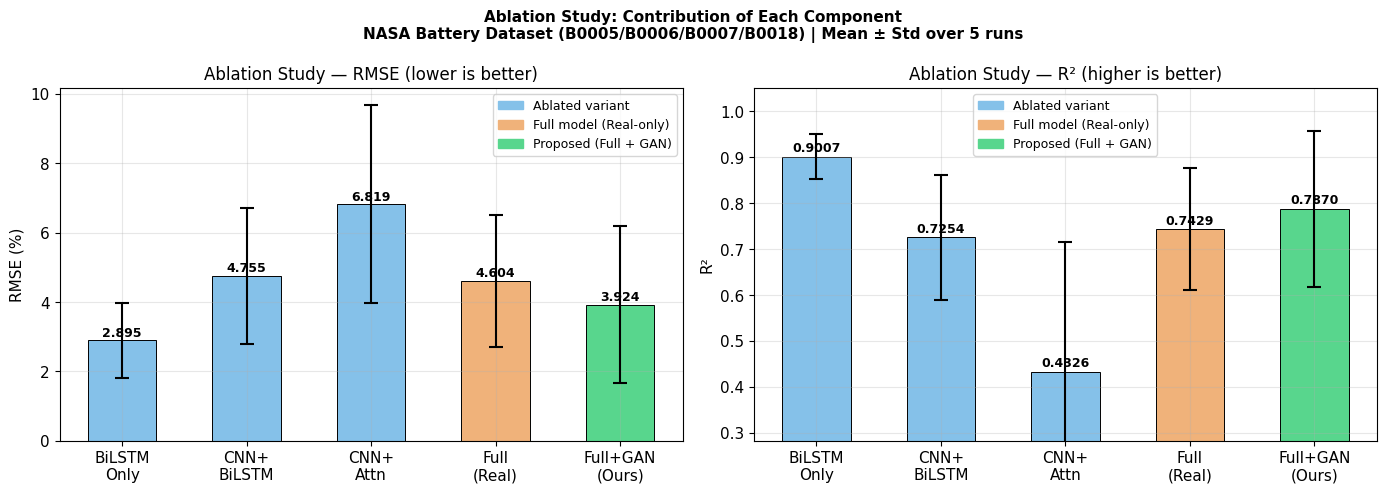

Saved: ablation_bar_chart.png


In [8]:
variants    = [r["variant"] for r in ablation_results]
rmse_means  = [r["RMSE_mean"] for r in ablation_results]
rmse_stds   = [r["RMSE_std"]  for r in ablation_results]
r2_means    = [r["R2_mean"]   for r in ablation_results]
r2_stds     = [r["R2_std"]    for r in ablation_results]

short_names = ["BiLSTM\nOnly", "CNN+\nBiLSTM", "CNN+\nAttn",
               "Full\n(Real)", "Full+GAN\n(Ours)"]
bar_colors  = ["#85C1E9","#85C1E9","#85C1E9","#F0B27A","#58D68D"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── RMSE bar chart ────────────────────────────────────────────────
bars = axes[0].bar(short_names, rmse_means, color=bar_colors,
                   edgecolor="black", linewidth=0.7, width=0.55)
axes[0].errorbar(short_names, rmse_means, yerr=rmse_stds,
                 fmt="none", color="black", capsize=5, capthick=1.5, lw=1.5)
axes[0].set_ylabel("RMSE (%)")
axes[0].set_title("Ablation Study — RMSE (lower is better)")
for bar, val in zip(bars, rmse_means):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

# ── R² bar chart ──────────────────────────────────────────────────
bars2 = axes[1].bar(short_names, r2_means, color=bar_colors,
                    edgecolor="black", linewidth=0.7, width=0.55)
axes[1].errorbar(short_names, r2_means, yerr=r2_stds,
                 fmt="none", color="black", capsize=5, capthick=1.5, lw=1.5)
axes[1].set_ylabel("R²")
axes[1].set_title("Ablation Study — R² (higher is better)")
axes[1].set_ylim([max(0, min(r2_means)-0.15), 1.05])
for bar, val in zip(bars2, r2_means):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{val:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

# Legend
legend_patches = [
    mpatches.Patch(color="#85C1E9", label="Ablated variant"),
    mpatches.Patch(color="#F0B27A", label="Full model (Real-only)"),
    mpatches.Patch(color="#58D68D", label="Proposed (Full + GAN)"),
]
axes[0].legend(handles=legend_patches, fontsize=9)
axes[1].legend(handles=legend_patches, fontsize=9)

plt.suptitle("Ablation Study: Contribution of Each Component\n"
             "NASA Battery Dataset (B0005/B0006/B0007/B0018) | Mean ± Std over 5 runs",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "ablation_bar_chart.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ablation_bar_chart.png")


---
## 📐 Cell 9 — Statistical Significance Tests

**What this cell does:**
Performs two statistical tests to verify that the performance difference between
**Full Model (Real-only)** and **Full Model + GAN (Proposed)** is statistically
significant — not just due to random variation in training.

---

**Test 1 — Paired t-test (parametric):**
- Assumes the RMSE differences across runs follow a normal distribution
- H₀ (null hypothesis): The mean RMSE of Real-only = mean RMSE of Augmented
- H₁ (alternative): They are different
- If p-value < 0.05 → reject H₀ → difference is statistically significant

**Test 2 — Wilcoxon Signed-Rank Test (non-parametric):**
- Does NOT assume normal distribution — more robust for small samples (N=5)
- H₀: The median RMSE difference = 0
- H₁: The medians are different
- If p-value < 0.05 → difference is statistically significant

**Why we run both tests:**
With only 5 runs, the normality assumption of t-test may not hold perfectly.
Running both and showing consistent results strengthens the statistical argument.

**Effect Size — Cohen's d:**
Statistical significance (p-value) tells us IF a difference exists.
Effect size tells us HOW LARGE the difference is.
- Cohen's d < 0.2: negligible
- Cohen's d 0.2-0.5: small
- Cohen's d 0.5-0.8: medium
- Cohen's d > 0.8: large

**We also test all variant pairs** to see which component additions are significant.


In [9]:
# ── Extract per-run RMSE for statistical testing ─────────────────
rmse_by_variant = {r["variant"]: r["rmse_runs"] for r in ablation_results}

real_only_rmse = np.array(rmse_by_variant["4. Full Model (Real-only)"])
augmented_rmse = np.array(rmse_by_variant["5. Full Model + GAN (Ours)"])

print("=" * 65)
print("STATISTICAL SIGNIFICANCE TESTS")
print("Comparing: Full Model (Real-only) vs Full Model + GAN (Ours)")
print("=" * 65)
print()
print(f"Real-only RMSE runs  : {[round(x,4) for x in real_only_rmse]}")
print(f"Augmented RMSE runs  : {[round(x,4) for x in augmented_rmse]}")
print(f"Mean difference (Real - Aug): {(real_only_rmse - augmented_rmse).mean():.4f}%")
print()

# ── Test 1: Paired t-test ────────────────────────────────────────
t_stat, t_pval = stats.ttest_rel(real_only_rmse, augmented_rmse)
print(f"Test 1 — Paired t-test:")
print(f"  t-statistic : {t_stat:.4f}")
print(f"  p-value     : {t_pval:.4f}")
print(f"  Significant : {'Yes ✅ (p < 0.05)' if t_pval < 0.05 else 'No ❌ (p >= 0.05)'}")
print()

# ── Test 2: Wilcoxon Signed-Rank Test ────────────────────────────
try:
    w_stat, w_pval = stats.wilcoxon(real_only_rmse, augmented_rmse)
    print(f"Test 2 — Wilcoxon Signed-Rank Test (non-parametric):")
    print(f"  W-statistic : {w_stat:.4f}")
    print(f"  p-value     : {w_pval:.4f}")
    print(f"  Significant : {'Yes ✅ (p < 0.05)' if w_pval < 0.05 else 'No ❌ (p >= 0.05)'}")
except Exception as e:
    print(f"Wilcoxon test note: {e}")
    print("  (Wilcoxon requires all differences != 0; may need more runs if tied)")
print()

# ── Effect Size: Cohen's d ────────────────────────────────────────
diff     = real_only_rmse - augmented_rmse
pooled_std = np.sqrt((np.std(real_only_rmse)**2 + np.std(augmented_rmse)**2) / 2)
cohens_d   = diff.mean() / (pooled_std + 1e-10)

def interpret_d(d):
    ad = abs(d)
    if ad < 0.2:  return "Negligible"
    elif ad < 0.5: return "Small"
    elif ad < 0.8: return "Medium"
    else:          return "Large"

print(f"Effect Size — Cohen's d:")
print(f"  d = {cohens_d:.4f}  →  {interpret_d(cohens_d)} effect")
print()

# ── All pairwise comparisons ──────────────────────────────────────
print("=" * 65)
print("PAIRWISE t-TEST BETWEEN ALL ADJACENT VARIANTS")
print("(Tests whether each component addition is significant)")
print("=" * 65)
variant_names = [r["variant"] for r in ablation_results]
pairwise_rows = []
for i in range(len(ablation_results)-1):
    a = np.array(ablation_results[i]["rmse_runs"])
    b = np.array(ablation_results[i+1]["rmse_runs"])
    t, p = stats.ttest_rel(a, b)
    pairwise_rows.append({
        "Comparison": f"{variant_names[i][:20]} vs {variant_names[i+1][:20]}",
        "Mean Diff":  round(a.mean() - b.mean(), 4),
        "t-stat":     round(t, 3),
        "p-value":    round(p, 4),
        "Significant":  "Yes ✅" if p < 0.05 else "No ❌",
    })
pw_df = pd.DataFrame(pairwise_rows)
print(pw_df.to_string(index=False))

# Save stats
stat_results = {
    "t_statistic": float(t_stat),
    "t_pvalue": float(t_pval),
    "cohens_d": float(cohens_d),
    "effect_size": interpret_d(cohens_d),
    "real_only_rmse_mean": float(real_only_rmse.mean()),
    "augmented_rmse_mean": float(augmented_rmse.mean()),
}
pd.DataFrame([stat_results]).to_csv(
    os.path.join(OUTPUT_DIR, "statistical_test_results.csv"), index=False
)
pw_df.to_csv(os.path.join(OUTPUT_DIR, "pairwise_ttest_results.csv"), index=False)
print()
print("Saved: statistical_test_results.csv, pairwise_ttest_results.csv")


STATISTICAL SIGNIFICANCE TESTS
Comparing: Full Model (Real-only) vs Full Model + GAN (Ours)

Real-only RMSE runs  : [np.float64(0.9146), np.float64(4.9959), np.float64(5.4003), np.float64(6.2457), np.float64(5.4654)]
Augmented RMSE runs  : [np.float64(1.0977), np.float64(6.4331), np.float64(5.6337), np.float64(5.1542), np.float64(1.3013)]
Mean difference (Real - Aug): 0.6804%

Test 1 — Paired t-test:
  t-statistic : 0.7099
  p-value     : 0.5169
  Significant : No ❌ (p >= 0.05)

Test 2 — Wilcoxon Signed-Rank Test (non-parametric):
  W-statistic : 7.0000
  p-value     : 1.0000
  Significant : No ❌ (p >= 0.05)

Effect Size — Cohen's d:
  d = 0.3265  →  Small effect

PAIRWISE t-TEST BETWEEN ALL ADJACENT VARIANTS
(Tests whether each component addition is significant)
                                  Comparison  Mean Diff  t-stat  p-value Significant
           1. BiLSTM Only vs 2. CNN + BiLSTM    -1.8598  -4.127   0.0145       Yes ✅
       2. CNN + BiLSTM vs 3. CNN + Attention    -2.0647 

---
## 📊 Cell 10 — Statistical Test Visualization

**What this cell does:**
Creates a clear visualization of the statistical comparison between
Real-only and Augmented models across all 5 training runs.

**Figure contents:**

**Left plot — RMSE per run (scatter + mean line):**
- Each dot = one training run
- Horizontal line = mean RMSE
- Shows the spread/variance of each approach
- If augmented points are consistently lower → augmentation helps reliably

**Right plot — RMSE difference per run:**
- Each bar = RMSE(Real-only) - RMSE(Augmented) for one run
- Green bar = augmented is better (positive difference)
- Red bar = real-only is better (negative difference)
- The p-value from the paired t-test is annotated on the plot

This figure is suitable for inclusion in the paper's statistical analysis section.


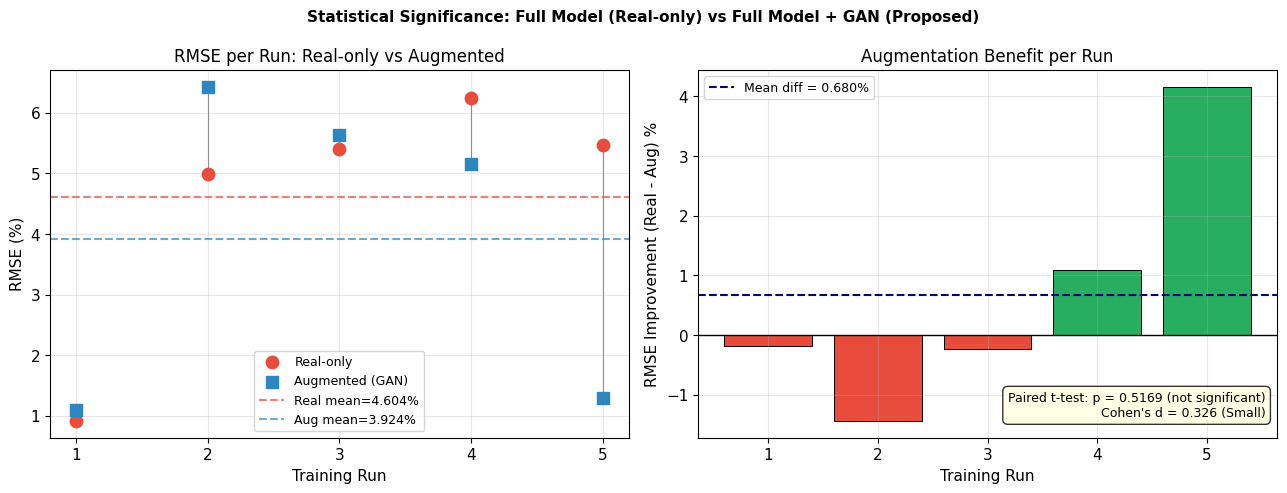

Saved: statistical_test_plot.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

runs = list(range(1, N_RUNS + 1))

# ── Left: per-run RMSE scatter ────────────────────────────────────
axes[0].scatter(runs, real_only_rmse, color="#E74C3C", s=80, zorder=3,
                label="Real-only", marker="o")
axes[0].scatter(runs, augmented_rmse, color="#2E86C1", s=80, zorder=3,
                label="Augmented (GAN)", marker="s")
axes[0].axhline(real_only_rmse.mean(), color="#E74C3C", linestyle="--",
                lw=1.5, alpha=0.7, label=f"Real mean={real_only_rmse.mean():.3f}%")
axes[0].axhline(augmented_rmse.mean(), color="#2E86C1", linestyle="--",
                lw=1.5, alpha=0.7, label=f"Aug mean={augmented_rmse.mean():.3f}%")
for i, (r, a) in enumerate(zip(real_only_rmse, augmented_rmse)):
    axes[0].plot([i+1, i+1], [r, a], color="gray", lw=0.8, zorder=1)

axes[0].set_xlabel("Training Run")
axes[0].set_ylabel("RMSE (%)")
axes[0].set_title("RMSE per Run: Real-only vs Augmented")
axes[0].legend(fontsize=9)
axes[0].set_xticks(runs)

# ── Right: difference bar chart ────────────────────────────────────
diffs = real_only_rmse - augmented_rmse
bar_colors2 = ["#27AE60" if d > 0 else "#E74C3C" for d in diffs]
bars = axes[1].bar(runs, diffs, color=bar_colors2, edgecolor="black", lw=0.7)
axes[1].axhline(0, color="black", lw=1, linestyle="-")
axes[1].axhline(diffs.mean(), color="navy", lw=1.5, linestyle="--",
                label=f"Mean diff = {diffs.mean():.3f}%")
axes[1].set_xlabel("Training Run")
axes[1].set_ylabel("RMSE Improvement (Real - Aug) %")
axes[1].set_title("Augmentation Benefit per Run")
axes[1].set_xticks(runs)
axes[1].legend(fontsize=9)

sig_str = f"p = {t_pval:.4f} ({'significant' if t_pval < 0.05 else 'not significant'})"
axes[1].text(0.98, 0.05, f"Paired t-test: {sig_str}\nCohen's d = {cohens_d:.3f} ({interpret_d(cohens_d)})",
             transform=axes[1].transAxes, ha="right", va="bottom",
             fontsize=9, bbox=dict(boxstyle="round,pad=0.4", facecolor="lightyellow", alpha=0.8))

plt.suptitle("Statistical Significance: Full Model (Real-only) vs Full Model + GAN (Proposed)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "statistical_test_plot.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: statistical_test_plot.png")


---
## ✅ Cell 11 — Final Summary & Paper-Ready Output

**What this cell does:**
Prints a clean, paper-ready summary of all results from this notebook.

**Outputs saved to `/kaggle/working`:**
| File | Contents |
|------|----------|
| `ablation_results.csv` | Mean ± Std table for all 5 variants |
| `ablation_results_raw.csv` | Raw mean values for all variants |
| `ablation_bar_chart.png` | Bar chart figure (for paper) |
| `statistical_test_results.csv` | t-test, Wilcoxon, Cohen's d |
| `pairwise_ttest_results.csv` | Pairwise t-tests between variants |
| `statistical_test_plot.png` | Statistical comparison figure (for paper) |

After running this notebook, create a Kaggle Dataset from the outputs and
include the figures and CSV files in the paper update.


In [11]:
print("=" * 70)
print("FINAL SUMMARY — ABLATION STUDY + STATISTICAL TESTS")
print("=" * 70)
print()
print("ABLATION RESULTS (Mean RMSE over 5 runs):")
print()
for r in ablation_results:
    bar = "█" * int(r["RMSE_mean"] * 5)
    print(f"  {r['variant']:<35} RMSE={r['RMSE_mean']:.4f}%  R²={r['R2_mean']:.4f}  {bar}")

print()
print(f"STATISTICAL TEST (Variant 4 vs Variant 5):")
print(f"  Paired t-test p-value : {t_pval:.4f} "
      f"({'SIGNIFICANT ✅' if t_pval < 0.05 else 'NOT SIGNIFICANT ❌'})")
print(f"  Cohen's d effect size : {cohens_d:.4f} ({interpret_d(cohens_d)})")
print()
print("FILES SAVED:")
saved_files = [
    "ablation_results.csv",
    "ablation_results_raw.csv",
    "ablation_bar_chart.png",
    "statistical_test_results.csv",
    "pairwise_ttest_results.csv",
    "statistical_test_plot.png",
]
for f in saved_files:
    path = os.path.join(OUTPUT_DIR, f)
    size = os.path.getsize(path) if os.path.exists(path) else 0
    print(f"  ✓ {f:<40} ({size:,} bytes)")

print()
print("Notebook complete. Ready to update paper.")


FINAL SUMMARY — ABLATION STUDY + STATISTICAL TESTS

ABLATION RESULTS (Mean RMSE over 5 runs):

  1. BiLSTM Only                      RMSE=2.8949%  R²=0.9007  ██████████████
  2. CNN + BiLSTM                     RMSE=4.7547%  R²=0.7254  ███████████████████████
  3. CNN + Attention                  RMSE=6.8194%  R²=0.4326  ██████████████████████████████████
  4. Full Model (Real-only)           RMSE=4.6044%  R²=0.7429  ███████████████████████
  5. Full Model + GAN (Ours)          RMSE=3.9240%  R²=0.7870  ███████████████████

STATISTICAL TEST (Variant 4 vs Variant 5):
  Paired t-test p-value : 0.5169 (NOT SIGNIFICANT ❌)
  Cohen's d effect size : 0.3265 (Small)

FILES SAVED:
  ✓ ablation_results.csv                     (405 bytes)
  ✓ ablation_results_raw.csv                 (241 bytes)
  ✓ ablation_bar_chart.png                   (104,724 bytes)
  ✓ statistical_test_results.csv             (182 bytes)
  ✓ pairwise_ttest_results.csv               (321 bytes)
  ✓ statistical_test_plot.png  